In [80]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, classification_report

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.utils import to_categorical

In [82]:
#Step 2: Load Dataset
df = pd.read_csv("glass.csv")

df.head()

,RI,Na,Mg,Al,Si,K,Ca,Ba,Fe,Type
0,1.52101,13.64,4.49,1.10,71.78,0.06,8.75,0.0,0.0,1
1,1.51761,13.89,3.60,1.36,72.73,0.48,7.83,0.0,0.0,1
2,1.51618,13.53,3.55,1.54,72.99,0.39,7.78,0.0,0.0,1
3,1.51766,13.21,3.69,1.29,72.61,0.57,8.22,0.0,0.0,1
4,1.51742,13.27,3.62,1.24,73.08,0.55,8.07,0.0,0.0,1


In [83]:
#Step 3: Check Dataset
print(df.shape)

print(df.info())

print(df.describe())

(214, 10)
<class 'pandas.DataFrame'>
RangeIndex: 214 entries, 0 to 213
Data columns (total 10 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   RI      214 non-null    float64
 1   Na      214 non-null    float64
 2   Mg      214 non-null    float64
 3   Al      214 non-null    float64
 4   Si      214 non-null    float64
 5   K       214 non-null    float64
 6   Ca      214 non-null    float64
 7   Ba      214 non-null    float64
 8   Fe      214 non-null    float64
 9   Type    214 non-null    int64  
dtypes: float64(9), int64(1)
memory usage: 16.8 KB
None
               RI          Na          Mg          Al          Si           K  \
count  214.000000  214.000000  214.000000  214.000000  214.000000  214.000000   
mean     1.518365   13.407850    2.684533    1.444907   72.650935    0.497056   
std      0.003037    0.816604    1.442408    0.499270    0.774546    0.652192   
min      1.511150   10.730000    0.000000    0.290000   69.810000    0.0

In [84]:
#Step 4: Check Missing Values
print(df.isnull().sum())

RI      0
Na      0
Mg      0
Al      0
Si      0
K       0
Ca      0
Ba      0
Fe      0
Type    0
dtype: int64


In [85]:

#Step 5: Check Target Classes
print(df['Type'].value_counts())

Type
2    76
1    70
7    29
3    17
5    13
6     9
Name: count, dtype: int64


In [86]:
#Step 6: Separate Features and Target
X = df.drop("Type", axis=1)

y = df["Type"]

In [87]:
#Step 7: Convert Classes to Start from 

y = y - 1

In [88]:
#Step 8: One Hot Encoding
y = to_categorical(y)

In [89]:
#Step 9: Feature Scaling
scaler = StandardScaler()

X = scaler.fit_transform(X)

In [90]:
#Step 10: Train Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [91]:
#Step 11: Build ANN Model
model = Sequential()

# First Hidden Layer
model.add(Dense(64, activation='relu', input_shape=(X_train.shape[1],)))
model.add(BatchNormalization())
model.add(Dropout(0.3))

# Second Hidden Layer
model.add(Dense(32, activation='relu'))
model.add(BatchNormalization())
model.add(Dropout(0.3))

# Third Hidden Layer
model.add(Dense(16, activation='relu'))
model.add(BatchNormalization())
model.add(Dropout(0.2))

# Output Layer
model.add(Dense(y.shape[1], activation='softmax'))

c:\Users\Lenovo\OneDrive\Desktop\Advance DSL\venv\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [92]:
#Step 12: Model Summary
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 16)             │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 7)              │           119 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,815 (14.90 KB)

 Trainable params: 3,591 (14.03 KB)

 Non-trainable params: 224 (896.00 B)

In [94]:
#Step 13: Compile Model
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [96]:
#Step 14: Train Model
history = model.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=16,
    validation_split=0.2
)

Epoch 1/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.6029 - loss: 1.1234 - val_accuracy: 0.6000 - val_loss: 1.2319
Epoch 2/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.5588 - loss: 1.2136 - val_accuracy: 0.6000 - val_loss: 1.2178
Epoch 3/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.6103 - loss: 1.0634 - val_accuracy: 0.6286 - val_loss: 1.2072
Epoch 4/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.6324 - loss: 1.0734 - val_accuracy: 0.6286 - val_loss: 1.2013
Epoch 5/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.6544 - loss: 1.0775 - val_accuracy: 0.6286 - val_loss: 1.2009
Epoch 6/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.6471 - loss: 1.0915 - val_accuracy: 0.6286 - val_loss: 1.1966
Epoch 7/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.6618 - loss: 1.0427 - val_accuracy: 0.6286 - val_loss: 1.1901
Epoch 8/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.6250 - loss: 1.0883 - val_accuracy: 0.6286 - val_loss: 1.1897


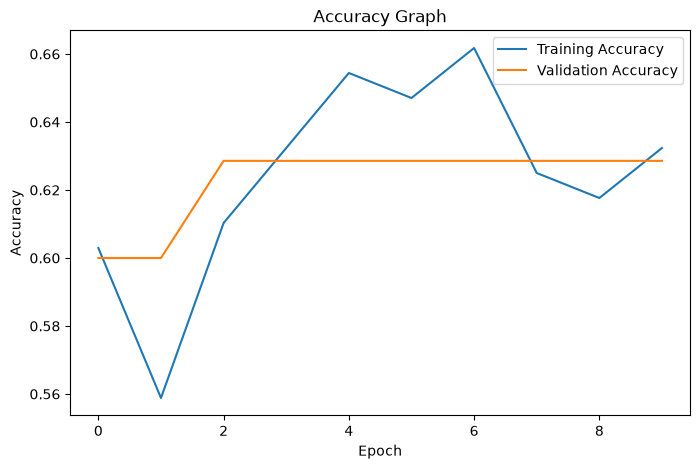

In [97]:
#Step 15: Accuracy Graph
plt.figure(figsize=(8,5))

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.xlabel("Epoch")

plt.ylabel("Accuracy")

plt.title("Accuracy Graph")

plt.legend()

plt.show()

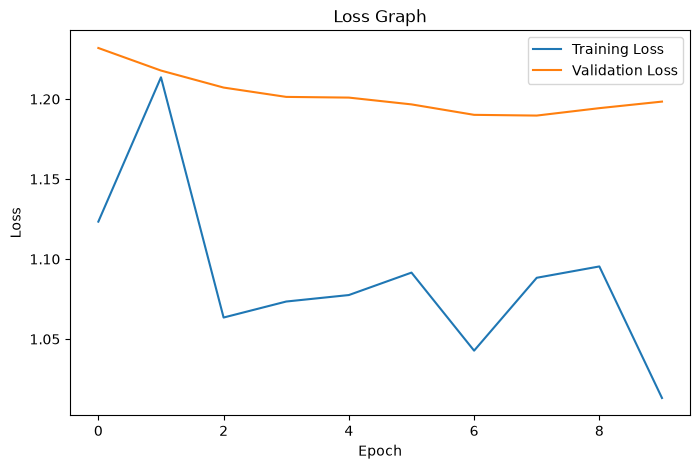

In [98]:
#Step 16: Loss Graph
plt.figure(figsize=(8,5))

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.title("Loss Graph")

plt.legend()

plt.show()

In [99]:
#Step 17: Evaluate Model
loss, accuracy = model.evaluate(X_test, y_test)

print("Test Loss :", loss)

print("Test Accuracy :", accuracy)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.7209 - loss: 0.8805
Test Loss : 0.8804552555084229
Test Accuracy : 0.7209302186965942


In [100]:
#Step 18: Prediction
y_pred = model.predict(X_test)

y_pred_classes = np.argmax(y_pred, axis=1)

y_true = np.argmax(y_test, axis=1)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 109ms/step


In [101]:
#Step 19: Confusion Matrix
cm = confusion_matrix(y_true, y_pred_classes)

print(cm)

[[10  1  0  0  0  0  0]
 [ 3 11  0  0  0  0  0]
 [ 1  2  0  0  0  0  0]
 [ 0  0  0  0  0  0  0]
 [ 0  3  0  0  1  0  0]
 [ 0  0  0  1  0  1  1]
 [ 0  0  0  0  0  0  8]]


In [102]:
#Step 20: Classification Report
print(classification_report(y_true, y_pred_classes))

              precision    recall  f1-score   support

           0       0.71      0.91      0.80        11
           1       0.65      0.79      0.71        14
           2       0.00      0.00      0.00         3
           3       0.00      0.00      0.00         0
           4       1.00      0.25      0.40         4
           5       1.00      0.33      0.50         3
           6       0.89      1.00      0.94         8

    accuracy                           0.72        43
   macro avg       0.61      0.47      0.48        43
weighted avg       0.72      0.72      0.68        43



c:\Users\Lenovo\OneDrive\Desktop\Advance DSL\venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Lenovo\OneDrive\Desktop\Advance DSL\venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Lenovo\OneDrive\Desktop\Advance DSL\venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metr

In [103]:
#Step 21: Save Model
model.save("Glass_ANN_Model.keras")

print("Model Saved Successfully")

Model Saved Successfully


In [104]:
print(df['Type'].value_counts())

Type
2    76
1    70
7    29
3    17
5    13
6     9
Name: count, dtype: int64
